# Empirical results

Run all cells to reproduce the three main-text figures and reported values.
Results are displayed below; no output files are written.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "legend.frameon": False})

## 1. Boolean functions

All functions for 2–4 inputs; 400,000 samples each for 5 and 6 inputs (seed
20260407). Compare refined MMI support with the smaller subset support under
inclusion and reverse inclusion.

In [2]:
PRIMES = (2, 3, 5, 7, 11, 13)

def entropy_vectors(size):
    """size*h(k/size) as integer coefficients of log2(prime)."""
    factors = np.zeros((size + 1, len(PRIMES)), dtype=np.int64)
    for x in range(1, size + 1):
        q = x
        for j, prime in enumerate(PRIMES):
            while q % prime == 0:
                factors[x, j] += x
                q //= prime
        assert q == 1
    return np.array([factors[size] - factors[k] - factors[size-k]
                     for k in range(size + 1)])


def exact_census(n):
    size = 1 << n
    tables = np.arange(1 << size, dtype=np.uint64)
    truth = ((tables[:, None] >> np.arange(size, dtype=np.uint64)) & 1).astype(int)
    entropy = {m: entropy_vectors(m) for m in [1 << i for i in range(n+1)]}
    global_h = entropy[size][truth.sum(axis=1)]
    values = np.zeros((len(tables), size, len(PRIMES)), dtype=np.int64)
    states = np.arange(size)
    for mask in range(1, size):
        blocksize = size >> mask.bit_count()
        conditional = np.zeros_like(global_h)
        for assignment in range(size):
            if assignment & mask == assignment:
                ones = truth[:, (states & mask) == assignment].sum(axis=1)
                conditional += entropy[blocksize][ones]
        values[:, mask] = global_h - conditional
    lower, upper = values.copy(), values.copy()
    for bit in range(n):
        for mask in range(size):
            if mask & (1 << bit):
                lower[:, mask] -= lower[:, mask ^ (1 << bit)]
            else:
                upper[:, mask] -= upper[:, mask | (1 << bit)]
    low_count = np.any(lower[:, 1:] != 0, axis=2).sum(axis=1)
    up_count = np.any(upper[:, 1:] != 0, axis=2).sum(axis=1)
    refined = np.array([len({tuple(v) for v in row[1:] if np.any(v)})
                        for row in values], dtype=np.int64)
    return tables, np.minimum(low_count, up_count), refined


@njit
def sampled_supports(tables, n):
    size = 1 << n
    entropy = np.zeros((size + 1, size + 1))
    for b in range(n + 1):
        m = 1 << b
        for k in range(1, m):
            p = k / m
            entropy[m, k] = m * (-p*np.log2(p) - (1-p)*np.log2(1-p))
    coarse = np.zeros(len(tables), dtype=np.int64)
    refined = np.zeros(len(tables), dtype=np.int64)
    for i, table in enumerate(tables):
        truth = np.array([(table >> np.uint64(x)) & np.uint64(1)
                          for x in range(size)], dtype=np.int64)
        values = np.zeros(size)
        for mask in range(1, size):
            counts = np.zeros(size, dtype=np.int64)
            bits = 0
            for b in range(n):
                bits += (mask >> b) & 1
            for x in range(size):
                counts[x & mask] += truth[x]
            conditional = 0.0
            for assignment in range(size):
                if assignment & mask == assignment:
                    conditional += entropy[size >> bits, counts[assignment]]
            values[mask] = (entropy[size, truth.sum()] - conditional) / size
        lower, upper = values.copy(), values.copy()
        for b in range(n):
            for mask in range(size):
                if mask & (1 << b):
                    lower[mask] -= lower[mask ^ (1 << b)]
                else:
                    upper[mask] -= upper[mask | (1 << b)]
        coarse[i] = min(np.sum(np.abs(lower[1:]) > 1e-12),
                        np.sum(np.abs(upper[1:]) > 1e-12))
        previous = 0.0
        for level in np.sort(np.round(values[1:], 14)):
            if level > previous:
                refined[i] += level - previous > 1e-12
                previous = level
    return coarse, refined

,Inputs,Functions,Subset mean,MMI mean,Subset SE,MMI SE
0,2,16,1.875000,1.375000,0.000000,0.000000
1,3,256,5.398438,3.210938,0.000000,0.000000
2,4,65536,13.222137,6.981537,0.000000,0.000000
3,5,400000,29.456563,15.647675,0.003775,0.004395
4,6,400000,61.775472,37.316300,0.003242,0.007726


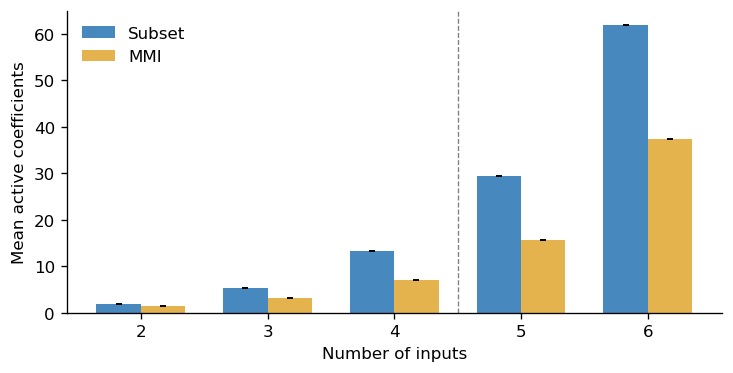

In [3]:
boolean_rows = []
for n in range(2, 7):
    if n <= 4:
        tables, coarse, refined = exact_census(n)
    else:
        tables = np.random.PCG64(20260407).random_raw(400_000)
        if n == 5:
            tables &= np.uint64((1 << 32) - 1)
        coarse, refined = sampled_supports(tables, n)
    boolean_rows.append({
        "Inputs": n, "Functions": len(tables),
        "Subset mean": coarse.mean(), "MMI mean": refined.mean(),
        "Subset SE": 0 if n <= 4 else coarse.std(ddof=1) / np.sqrt(len(tables)),
        "MMI SE": 0 if n <= 4 else refined.std(ddof=1) / np.sqrt(len(tables)),
    })

boolean_results = pd.DataFrame(boolean_rows)
display(boolean_results)
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
for j, (name, color) in enumerate([("Subset", "#4789be"), ("MMI", "#e5b34d")]):
    ax.bar(np.arange(5) + (j - .5)*.35, boolean_results[f"{name} mean"],
           width=.35, color=color, label=name,
           yerr=1.96*boolean_results[f"{name} SE"], capsize=2)
ax.set(xticks=np.arange(5), xticklabels=range(2, 7),
       xlabel="Number of inputs", ylabel="Mean active coefficients")
ax.axvline(2.5, color=".5", linestyle="--", linewidth=.8)
ax.legend()
plt.show()

## 2. Protein calculations

Median-binarize the 11 proteins and calculate $I(X_A;C)$ for all 2,047
nonempty coalitions, with experimental condition as the target.
Data: [Sachs et al., via Zenodo](https://doi.org/10.5281/zenodo.7681811), CC BY 4.0.

In [4]:
archive = Path("data/sachs_zenodo.zip")
if not archive.exists():
    archive = Path("reproducibilty_notebook") / archive
files = ["cd3cd28.csv", "cd3cd28_icam2.csv", "cd3cd28_aktinhib.csv",
         "cd3cd28_g0076.csv", "cd3cd28_psitect.csv", "cd3cd28_u0126.csv",
         "cd3cd28_ly.csv", "pma.csv", "b2camp.csv"]
with ZipFile(archive) as z:
    frames = [pd.read_csv(z.open("Data Files/" + name)) for name in files]
data = pd.concat(frames, ignore_index=True)
proteins = [p for p in data.columns if p != "Erk"] + ["Erk"]
binary = (data[proteins] > data[proteins].median()).to_numpy(dtype=np.int64)
labels = np.repeat(np.arange(9), [len(frame) for frame in frames])
states = (binary * (1 << np.arange(11))).sum(axis=1)
counts = np.vstack([np.bincount(states[labels == c], minlength=2048) for c in range(9)])

# Compact tables for all subset marginals.
N_STATES = 2048
offsets = np.zeros(N_STATES, dtype=np.int64)
lengths = np.array([1 << m.bit_count() for m in range(N_STATES)])
offsets[1:] = np.cumsum(lengths[:-1])
removed_ranks = np.zeros(N_STATES, dtype=np.int64)
for mask in range(N_STATES - 1):
    missing_bit = ((~mask) & 2047) & -((~mask) & 2047)
    removed_ranks[mask] = (mask & (missing_bit - 1)).bit_count()

In [5]:
@njit(cache=False)
def all_subset_entropies(counts, offsets, lengths, removed_ranks):
    """All marginal plug-in entropies (bits) from a full binary count table."""
    n_states = counts.size
    full_mask = n_states - 1
    distributions = np.empty(offsets[-1] + lengths[-1], dtype=np.float64)
    entropies = np.empty(n_states, dtype=np.float64)
    n_observations = counts.sum()

    full_offset = offsets[full_mask]
    for state in range(n_states):
        distributions[full_offset + state] = counts[state] / n_observations

    # Adding the least missing bit gives a numerically larger, already-computed
    # canonical parent. Remove that bit from its compact marginal table.
    for mask in range(full_mask, -1, -1):
        offset = offsets[mask]
        length = lengths[mask]
        if mask != full_mask:
            missing = (~mask) & full_mask
            least_missing = missing & -missing
            parent = mask | least_missing
            rank = removed_ranks[mask]
            parent_offset = offsets[parent]
            low_mask = (1 << rank) - 1
            for compact_state in range(length):
                low = compact_state & low_mask
                high = compact_state >> rank
                parent_zero = low | (high << (rank + 1))
                distributions[offset + compact_state] = (
                    distributions[parent_offset + parent_zero]
                    + distributions[parent_offset + parent_zero + (1 << rank)]
                )

        entropy = 0.0
        for compact_state in range(length):
            probability = distributions[offset + compact_state]
            if probability > 0.0:
                entropy -= probability * np.log2(probability)
        entropies[mask] = entropy
    return entropies


def condition_target_mi(counts_by_condition: np.ndarray) -> np.ndarray:
    """All empirical I(X_A; condition) values for nonempty protein sets A."""
    pooled_entropy = all_subset_entropies(
        counts_by_condition.sum(axis=0), offsets, lengths, removed_ranks
    )
    within_entropy = np.zeros(N_STATES, dtype=np.float64)
    total = counts_by_condition.sum()
    for counts in counts_by_condition:
        within_entropy += (
            counts.sum() / total
            * all_subset_entropies(counts, offsets, lengths, removed_ranks)
        )
    values = pooled_entropy - within_entropy
    return np.maximum(values[1:], 0.0)


def generators(values, threshold):
    inside = np.r_[False, values >= threshold - 1e-12]
    return [m for m in range(1, 2048) if inside[m] and all(
        not (m & (1 << b)) or not inside[m ^ (1 << b)] for b in range(11))]


def fixed_chain(values, order):
    ordered = values[order]
    return np.maximum(np.minimum.accumulate(ordered[::-1])[::-1]
                      - np.r_[0, np.maximum.accumulate(ordered)[:-1]], 0)


def fixed_atom(values, inside):
    return max(values[inside].min() - max(0, values[~inside].max(initial=0)), 0)


protein_values = condition_target_mi(counts)
order = np.argsort(protein_values, kind="stable")
levels = protein_values[order]
masses = np.diff(np.r_[0, levels])
print(f"{len(data):,} cells; {len(masses):,} positive atoms; total {masses.sum():.9f} bits")

7,466 cells; 2,047 positive atoms; total 2.109474844 bits


### Bootstrap bands

1,000 condition-stratified resamples, evaluated at the original atom labels
(seed 20260824).

In [6]:
rng = np.random.default_rng(20260824)
bootstrap = np.empty((1000, len(masses)))
for b in range(1000):
    sampled = np.vstack([rng.multinomial(int(c.sum()), c / c.sum()) for c in counts])
    bootstrap[b] = fixed_chain(condition_target_mi(sampled), order)
pointwise = np.quantile(bootstrap, [.025, .975], axis=0)
q = np.quantile(np.abs(bootstrap - masses).max(axis=1), .95, method="higher")
supported = np.flatnonzero(masses > q)
atom_rows = []
for i in supported:
    routes = generators(protein_values, levels[i])
    sizes = sorted(set(m.bit_count() for m in routes))
    atom_rows.append({"Rank": i + 1, "Mass (bits)": masses[i],
                      "Pointwise lower": pointwise[0, i], "Pointwise upper": pointwise[1, i],
                      "Simultaneous lower": masses[i] - q, "Simultaneous upper": masses[i] + q,
                      "Routes": len(routes), "Proteins per route": str(sizes)})
protein_results = pd.DataFrame(atom_rows)
print(f"Pointwise-positive atoms: {(pointwise[0] > 0).sum()}; simultaneous-positive atoms: {len(supported)}")
display(protein_results)

Pointwise-positive atoms: 12; simultaneous-positive atoms: 3


,Rank,Mass (bits),Pointwise lower,Pointwise upper,Simultaneous lower,Simultaneous upper,Routes,Proteins per route
0,1,0.104145,0.092982,0.117478,0.064612,0.143677,11,[1]
1,2038,0.047620,0.028394,0.060554,0.008087,0.087152,9,[10]
2,2047,0.147605,0.148777,0.169729,0.108072,0.187137,1,[11]


### Split validation

Stratified 50/50 split (seed 20260824). Select the largest discovery atom with
multiple minimal routes, each containing at least two proteins. Evaluate its
fixed label in validation and in 1,000 validation-label permutations
(seed 20260826).

,Data,Coefficient (bits)
0,Full,0.047620
1,Discovery,0.042923
2,Validation,0.047020


Validation permutation p = 0.000999


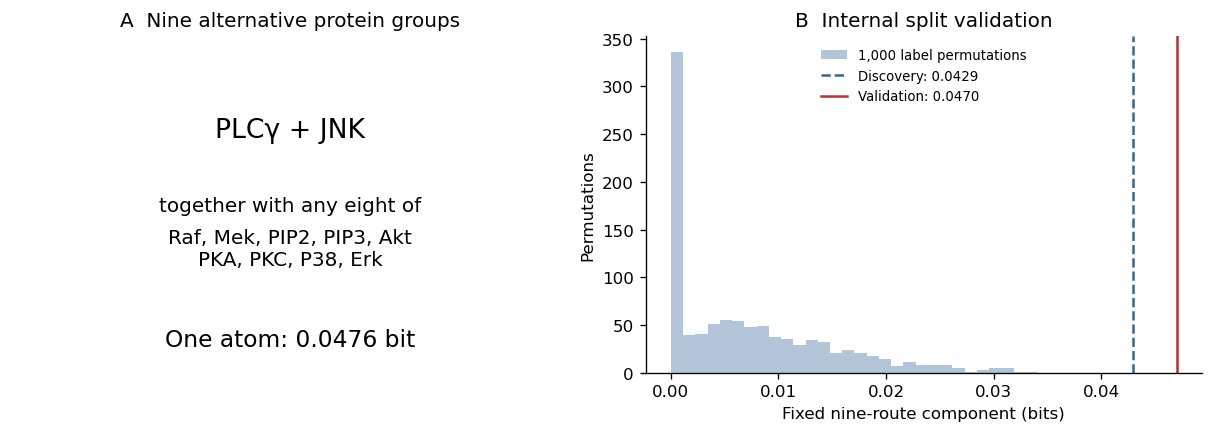

In [7]:
rng = np.random.default_rng(20260824)
discovery_indices, validation_indices = [], []
for c in range(9):
    indices = rng.permutation(np.flatnonzero(labels == c))
    midpoint = len(indices) // 2
    discovery_indices.append(indices[:midpoint])
    validation_indices.append(indices[midpoint:])

def subset_counts(groups):
    return np.vstack([np.bincount(states[g], minlength=2048) for g in groups])

discovery_values = condition_target_mi(subset_counts(discovery_indices))
validation_values = condition_target_mi(subset_counts(validation_indices))
discovery_levels = np.unique(discovery_values)
discovery_masses = np.diff(np.r_[0, discovery_levels])
for i in np.argsort(discovery_masses)[::-1]:
    routes = generators(discovery_values, discovery_levels[i])
    if len(routes) > 1 and min(m.bit_count() for m in routes) >= 2:
        selector = discovery_values >= discovery_levels[i] - 1e-12
        break
discovery_mass = fixed_atom(discovery_values, selector)
validation_mass = fixed_atom(validation_values, selector)
full_data_mass = fixed_atom(protein_values, selector)

pool = np.concatenate(validation_indices)
rng = np.random.default_rng(20260826)
validation_null = np.empty(1000)
for b in range(1000):
    shuffled = rng.permutation(labels[pool])
    sampled = np.bincount(shuffled*2048 + states[pool], minlength=9*2048).reshape(9, 2048)
    validation_null[b] = fixed_atom(condition_target_mi(sampled), selector)
p_value = (1 + np.count_nonzero(validation_null >= validation_mass)) / 1001
display(pd.DataFrame({"Data": ["Full", "Discovery", "Validation"],
                      "Coefficient (bits)": [full_data_mass, discovery_mass, validation_mass]}))
print(f"Validation permutation p = {p_value:.6f}")

common = set.intersection(*[{proteins[b] for b in range(11) if m & (1 << b)} for m in routes])
others = [p for p in proteins if p not in common]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].axis("off")
axes[0].set_title("A  Nine alternative protein groups")
axes[0].text(.5, .7, "PLCγ + JNK", ha="center", fontsize=16)
axes[0].text(.5, .48, "together with any eight of", ha="center", fontsize=12)
axes[0].text(.5, .32, ", ".join(others[:5]) + "\n" + ", ".join(others[5:]),
             ha="center", fontsize=12)
axes[0].text(.5, .08, f"One atom: {full_data_mass:.4f} bit", ha="center", fontsize=14)
axes[1].hist(validation_null, bins=30, color="#b4c4d9", label="1,000 label permutations")
axes[1].axvline(discovery_mass, linestyle="--", color="#37678e", label=f"Discovery: {discovery_mass:.4f}")
axes[1].axvline(validation_mass, color="#b43232", label=f"Validation: {validation_mass:.4f}")
axes[1].set(title="B  Internal split validation", xlabel="Fixed nine-route component (bits)", ylabel="Permutations")
axes[1].legend(fontsize=8)
plt.show()

## 3. Quantum states

10-qubit GHZ, ring-cluster, and 20 Haar states (seed 20260902).
For each partition, sum its block entropies. Round correlations to 12 decimal
places and take gaps between distinct positive levels to obtain the spectrum.

,State,Active coefficients
0,GHZ,9
1,Ring cluster,8
2,Haar 01,115974
3,Haar 02,115974
4,Haar 03,115974
5,Haar 04,115974
6,Haar 05,115974
7,Haar 06,115974
8,Haar 07,115974
9,Haar 08,115974


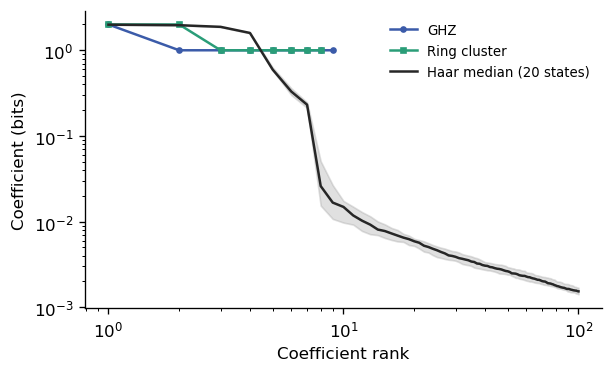

In [8]:
def set_partitions(n):
    """All set partitions of range(n), canonically ordered by least element."""
    parts = [()]
    for q in range(n):
        bit = 1 << q
        nxt = []
        for pi in parts:
            nxt.append(pi + (bit,))
            for j in range(len(pi)):
                merged = list(pi)
                merged[j] |= bit
                nxt.append(tuple(merged))
        parts = nxt
    return tuple(parts)


def ghz_state(n):
    psi = np.zeros(2**n, dtype=complex)
    psi[0] = psi[-1] = 1 / np.sqrt(2)
    return psi


def subsystem_entropy_pure(psi, keep, n, tol=1e-14):
    """Von Neumann entropy S(rho_keep), in bits, from Schmidt coefficients."""
    keep = tuple(sorted(keep))
    if len(keep) in (0, n):
        return 0.0
    rest = tuple(q for q in range(n) if q not in keep)
    tensor = np.asarray(psi, dtype=complex).reshape((2,) * n)
    matrix = np.transpose(tensor, keep + rest).reshape(2**len(keep), -1)
    probs = np.linalg.svd(matrix, compute_uv=False)**2
    probs = probs[probs > tol]
    return float(-np.sum(probs * np.log2(probs)))


def graph_state(n, edges):
    """Graph state obtained by applying CZ on the supplied edges to |+>^n."""
    psi = np.ones(2**n, dtype=complex) / np.sqrt(2**n)
    for basis in range(2**n):
        bits = [(basis >> (n - 1 - q)) & 1 for q in range(n)]
        parity = sum(bits[u] * bits[v] for u, v in edges) % 2
        if parity:
            psi[basis] *= -1
    return psi


partitions = set_partitions(10)
edges = [(q, (q + 1) % 10) for q in range(10)]
quantum_states = [("GHZ", ghz_state(10)), ("Ring cluster", graph_state(10, edges))]
rng = np.random.default_rng(20260902)
for i in range(20):
    psi = rng.normal(size=1024) + 1j*rng.normal(size=1024)
    quantum_states.append((f"Haar {i+1:02}", psi / np.linalg.norm(psi)))

spectra, quantum_rows = [], []
for name, psi in quantum_states:
    entropies = [subsystem_entropy_pure(psi, [q for q in range(10) if mask & (1 << q)], 10)
                 for mask in range(1024)]
    profile = np.array([sum(entropies[b] for b in pi) for pi in partitions])
    profile[np.abs(profile) < 1e-10] = 0
    profile = np.round(profile, 12)
    levels = np.unique(profile[profile > 1e-10])
    weights = np.diff(np.r_[0, levels])
    spectra.append(np.sort(weights)[::-1])
    quantum_rows.append({"State": name, "Active coefficients": len(weights)})
quantum_results = pd.DataFrame(quantum_rows)
display(quantum_results)

fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
for i, (label, color, marker) in enumerate([("GHZ", "#3b5ba9", "o"), ("Ring cluster", "#2a9d78", "s")]):
    ax.plot(np.arange(1, len(spectra[i])+1), spectra[i], color=color, marker=marker, markersize=3, label=label)
lo, median, hi = np.percentile(np.array([s[:100] for s in spectra[2:]]), [10, 50, 90], axis=0)
ranks = np.arange(1, 101)
ax.plot(ranks, median, color=".15", label="Haar median (20 states)")
ax.fill_between(ranks, lo, hi, color=".6", alpha=.3)
ax.set(xscale="log", yscale="log", xlabel="Coefficient rank", ylabel="Coefficient (bits)")
ax.legend(fontsize=8)
plt.show()